# Unsupervised model: K-Means

This notebook follows a simple unsupervised setup.

- **train** = rows where `fraud == "unknown"`
- **test** = rows where `fraud == "fraud"`
- the label is only used to split the data and check the results later
- the model is trained **without** using the label as an input feature

So this is not a regular supervised classification problem.

What I want to check here is:

1. does the `unknown` set show any natural structure on its own?
2. after fitting K-Means on that `unknown` set, do the `fraud` rows look far enough from the learned cluster centers to be treated as anomalous?

In this notebook, K-Means is used as a simple anomaly detection baseline by measuring the distance from each point to its nearest centroid.

For this experiment, I keep `k=3` as requested.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy import sparse

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import OneClassSVM

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Config

In [2]:
DATA_PATH = "fraud_data_encoded_v2.csv"

LABEL_COL = "fraud"
TRAIN_LABEL = "unknown"
TEST_LABEL = "fraud"

RANDOM_STATE = 42
KMEANS_K = 3
KMEANS_DISTANCE_QUANTILE = 0.99

OCSVM_KERNEL = "rbf"
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"

MAX_CATEGORICAL_LEVELS = 30
MAX_CATEGORICAL_RATIO = 0.05
MAX_MISSING_RATE = 0.98
SVD_MAX_COMPONENTS = 50

FLAG_MAPPINGS = {
    "ocr_tampering_flag": {"yes": 1, "no": 0},
    "front_liveness_fakeprint": {"true": 1, "false": 0},
    "back_liveness_fakeprint": {"true": 1, "false": 0},
    "front_object_liveness": {"success": 1, "failure": 0},
    "back_object_liveness": {"success": 1, "failure": 0},
    "liveness3d_object_liveness": {"success": 1, "failure": 0},
}

NUMERIC_COLS = ["tampering_flag", "year", "month", "day"]

DROP_NAME_KEYWORDS = [
    "uuid",
    "hash",
    "embedding",
    "image",
    "img",
    "photo",
    "avatar",
    "base64",
    "filepath",
    "filename",
    "sessionid",
]

MANUAL_DROP_COLS = [
    "tokenid",
    "ocr_cccd",
    "finger_print",
    "client_session",
    "facecompare_uuid",
    "liveness3d_uuid",
    "geolite_ipaddress",
]

## 2. Helpers

Nothing fancy here. I just keep the preprocessing and feature selection in a few small functions so the notebook stays readable.

In [3]:
def normalize_text(series):
    return series.astype("string").str.strip().str.lower()


def safe_map(series, mapping):
    return normalize_text(series).map(mapping)


def preprocess_data(df):
    data = df.copy()

    for col, mapping in FLAG_MAPPINGS.items():
        if col in data.columns:
            data[col] = safe_map(data[col], mapping)

    for col in NUMERIC_COLS:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    if LABEL_COL in data.columns:
        data["target"] = normalize_text(data[LABEL_COL]).map({
            TRAIN_LABEL: 0,
            TEST_LABEL: 1,
        })

    return data


def pick_feature_columns(df, label_col):
    keep_cols = []
    dropped_rows = []

    for col in df.columns:
        if col in {label_col, "target"}:
            dropped_rows.append({"column": col, "reason": "label"})
            continue

        series = df[col]
        nunique = series.nunique(dropna=False)
        missing_rate = series.isna().mean()
        unique_ratio = nunique / len(df)

        if col in MANUAL_DROP_COLS:
            dropped_rows.append({"column": col, "reason": "manual_drop"})
            continue

        if any(keyword in col.lower() for keyword in DROP_NAME_KEYWORDS):
            dropped_rows.append({"column": col, "reason": "name_rule"})
            continue

        if nunique <= 1:
            dropped_rows.append({"column": col, "reason": "single_value"})
            continue

        if missing_rate >= MAX_MISSING_RATE:
            dropped_rows.append({"column": col, "reason": "too_many_missing"})
            continue

        if pd.api.types.is_numeric_dtype(series):
            keep_cols.append(col)
            continue

        if nunique <= MAX_CATEGORICAL_LEVELS and unique_ratio <= MAX_CATEGORICAL_RATIO:
            keep_cols.append(col)
        else:
            dropped_rows.append({"column": col, "reason": "high_cardinality_text"})

    dropped_df = pd.DataFrame(dropped_rows).sort_values(["reason", "column"]).reset_index(drop=True)
    return keep_cols, dropped_df


def make_preprocessor(df, feature_cols):
    numeric_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, categorical_cols


def make_dense_representation(X_train, X_test, max_components=50, random_state=42):
    if sparse.issparse(X_train):
        max_valid = min(X_train.shape[0] - 1, X_train.shape[1] - 1, max_components)

        if max_valid >= 2:
            svd = TruncatedSVD(n_components=max_valid, random_state=random_state)
            X_train_dense = svd.fit_transform(X_train)
            X_test_dense = svd.transform(X_test)

            scaler = StandardScaler()
            X_train_dense = scaler.fit_transform(X_train_dense)
            X_test_dense = scaler.transform(X_test_dense)

            info = {
                "used_svd": True,
                "n_components": max_valid,
                "input_dim": X_train.shape[1],
                "output_dim": X_train_dense.shape[1],
            }
            return X_train_dense, X_test_dense, info

        X_train_dense = X_train.toarray()
        X_test_dense = X_test.toarray()
    else:
        X_train_dense = np.asarray(X_train)
        X_test_dense = np.asarray(X_test)

    scaler = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense)
    X_test_dense = scaler.transform(X_test_dense)

    info = {
        "used_svd": False,
        "n_components": None,
        "input_dim": X_train_dense.shape[1],
        "output_dim": X_train_dense.shape[1],
    }
    return X_train_dense, X_test_dense, info


def plot_pca_clusters(X, cluster_labels, title):
    if X.shape[1] < 2:
        print("PCA plot skipped because the feature space is less than 2D.")
        return

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)

    plt.figure(figsize=(8, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, s=14, alpha=0.75)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def distance_summary(train_dist, test_dist, quantiles=(0.95, 0.99, 1.00)):
    rows = []

    for q in quantiles:
        if q < 1.0:
            threshold = float(np.quantile(train_dist, q))
            label = f"q={q:.2f}"
        else:
            threshold = float(np.max(train_dist))
            label = "max(train)"

        train_flag = train_dist > threshold
        test_flag = test_dist > threshold

        rows.append({
            "threshold_rule": label,
            "threshold_value": threshold,
            "train_flagged_rate": float(train_flag.mean()),
            "test_flagged_rate": float(test_flag.mean()),
        })

    return pd.DataFrame(rows)


def show_hist(train_values, test_values, title, xlabel):
    plt.figure(figsize=(8, 4))
    plt.hist(train_values, bins=40, alpha=0.7, label="train: unknown")
    plt.hist(test_values, bins=40, alpha=0.7, label="test: fraud")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3. Load the data and split it the way we agreed

The split is fully label-based, but the label does **not** go into the model features.

- train = all `unknown`
- test = all `fraud`

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df = preprocess_data(df_raw)

label_counts = normalize_text(df[LABEL_COL]).value_counts(dropna=False).rename_axis(LABEL_COL).reset_index(name="count")
display(label_counts)

train_mask = normalize_text(df[LABEL_COL]) == TRAIN_LABEL
test_mask = normalize_text(df[LABEL_COL]) == TEST_LABEL

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print(f"Full data shape  : {df.shape}")
print(f"Train shape      : {train_df.shape}  (all '{TRAIN_LABEL}')")
print(f"Test shape       : {test_df.shape}  (all '{TEST_LABEL}')")

,fraud,count
0,unknown,31293
1,fraud,39


Full data shape  : (31332, 46)
Train shape      : (31293, 46)  (all 'unknown')
Test shape       : (39, 46)  (all 'fraud')


## 4. Pick a usable feature set

I do **not** want to throw raw IDs, UUIDs, hash-like columns, image paths, or huge text-cardinality columns straight into the models.

So the feature selection below keeps things fairly conservative:

- keep numeric columns
- keep small categorical columns
- drop the label
- drop obviously leak-prone or ID-like fields
- drop columns that are nearly all missing

In [5]:
feature_cols, dropped_feature_info = pick_feature_columns(train_df, LABEL_COL)

print(f"Columns kept for modeling: {len(feature_cols)}")
print(f"Columns dropped         : {len(dropped_feature_info)}")

display(pd.DataFrame({"feature_col": feature_cols}).head(50))
display(dropped_feature_info.head(50))

if len(feature_cols) == 0:
    raise ValueError("No feature columns left after filtering. Please loosen the feature selection rules.")

Columns kept for modeling: 19
Columns dropped         : 27


,feature_col
0,req_path
1,req_timestamplog
2,res_timestamplog
3,ocr_tampering_flag
4,month
5,day
6,front_liveness_fakeprint
7,front_object_liveness
8,liveness_timestamplog_front
9,liveness_timestamplog_back


,column,reason
0,city,high_cardinality_text
1,flag_123456,high_cardinality_text
2,ipaddress,high_cardinality_text
3,ma_may,high_cardinality_text
4,os_version,high_cardinality_text
5,fraud,label
6,target,label
7,client_session,manual_drop
8,facecompare_uuid,manual_drop
9,finger_print,manual_drop


In [6]:
X_train_df = train_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()

preprocessor, numeric_cols, categorical_cols = make_preprocessor(train_df, feature_cols)

X_train_pre = preprocessor.fit_transform(X_train_df)
X_test_pre = preprocessor.transform(X_test_df)

X_train_model, X_test_model, dim_info = make_dense_representation(
    X_train_pre,
    X_test_pre,
    max_components=SVD_MAX_COMPONENTS,
    random_state=RANDOM_STATE,
)

print("Numeric columns     :", len(numeric_cols))
print("Categorical columns :", len(categorical_cols))
print("Matrix info         :", dim_info)
print("Final train shape   :", X_train_model.shape)
print("Final test shape    :", X_test_model.shape)

Numeric columns     : 17
Categorical columns : 2
Matrix info         : {'used_svd': False, 'n_components': None, 'input_dim': 23, 'output_dim': 23}
Final train shape   : (31293, 23)
Final test shape    : (39, 23)


## K-Means

Fit on the unlabeled train set, then use **distance to the nearest centroid** as an anomaly score.
The threshold is derived entirely from the train distribution — no test labels involved.

> `unknown` ≠ `normal`. The train set may contain hidden fraud,
> which will blur the model's picture of normal behavior.

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=20)
kmeans.fit(X_train_model)

# anomaly score = distance to nearest centroid
train_dist = kmeans.transform(X_train_model).min(axis=1)
test_dist  = kmeans.transform(X_test_model).min(axis=1)

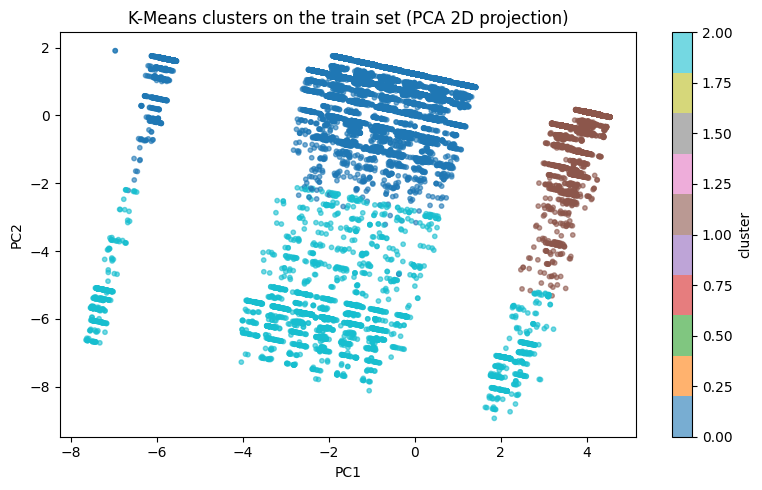

In [8]:
from sklearn.decomposition import PCA

# project down to 2D just for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_train_model)

train_clusters = kmeans.labels_

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(coords[:, 0], coords[:, 1],
                     c=train_clusters, cmap="tab10",
                     s=10, alpha=0.6)
ax.set_title("K-Means clusters on the train set (PCA 2D projection)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

In [9]:
# threshold from train distribution — no test labels used here
threshold = float(np.quantile(train_dist, KMEANS_DISTANCE_QUANTILE))

km_pred_train = (train_dist > threshold).astype(int)
km_pred_test  = (test_dist  > threshold).astype(int)

print(f"Threshold (q={KMEANS_DISTANCE_QUANTILE}): {threshold:.4f}")
print(f"Train flagged : {km_pred_train.sum()} / {len(km_pred_train)}  ({km_pred_train.mean():.2%})")
print(f"Test  flagged : {km_pred_test.sum()} / {len(km_pred_test)}   ({km_pred_test.mean():.2%})")

Threshold (q=0.99): 7.8631
Train flagged : 313 / 31293  (1.00%)
Test  flagged : 39 / 39   (100.00%)


In [10]:
# recall on the 39 confirmed fraud rows
n_fraud = len(test_dist)
caught  = int(km_pred_test.sum())
print(f"Recall on {n_fraud} fraud: {caught}/{n_fraud} = {caught/n_fraud:.1%}")

# Recall@top-K% — rank by anomaly score descending
rows = []
for pct in [1, 5, 10, 20, 50, 100]:
    k        = max(1, int(np.ceil(n_fraud * pct / 100)))
    top_idx  = np.argsort(test_dist)[-k:]
    caught_k = len(top_idx)
    rows.append({"top_%": pct, "k": k, "fraud_caught": caught_k,
                 "recall": round(caught_k / n_fraud, 4)})

display(pd.DataFrame(rows))

Recall on 39 fraud: 39/39 = 100.0%


,top_%,k,fraud_caught,recall
0,1,1,1,0.0256
1,5,2,2,0.0513
2,10,4,4,0.1026
3,20,8,8,0.2051
4,50,20,20,0.5128
5,100,39,39,1.0000


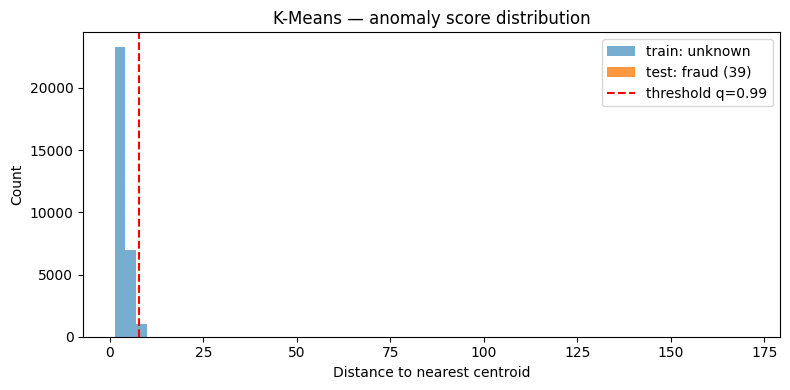

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_dist, bins=60, alpha=0.6, label="train: unknown")
ax.hist(test_dist,  bins=20, alpha=0.8, label="test: fraud (39)")
ax.axvline(threshold, color="red", linestyle="--",
           label=f"threshold q={KMEANS_DISTANCE_QUANTILE}")
ax.set_xlabel("Distance to nearest centroid")
ax.set_ylabel("Count")
ax.set_title("K-Means — anomaly score distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance analysis

Three complementary views — none of these models has a built-in importance score,
so we approximate from three angles:

1. **Feature–score correlation** — which features correlate most with the anomaly score
2. **Permutation importance** — shuffle each feature, measure how much the score changes
3. **Mean value by cluster / prediction group** — which features look different in flagged vs normal rows


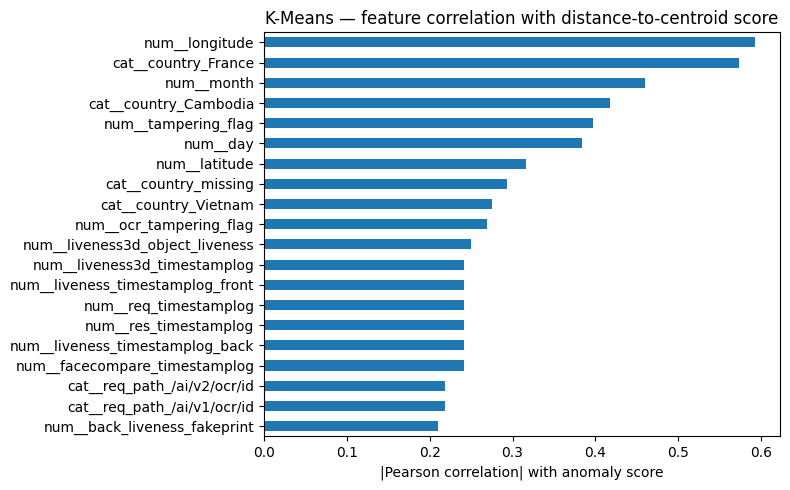

In [12]:
# --- 1. correlation between each feature and the anomaly score ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# X_train_model is a numpy array; get original feature names from the preprocessor
try:
    feat_names = (preprocessor
                  .get_feature_names_out()
                  .tolist())
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_model.shape[1])]

df_train = pd.DataFrame(X_train_model, columns=feat_names)
df_train["anomaly_score"] = train_dist

corr = (df_train.corr()["anomaly_score"]
        .drop("anomaly_score")
        .abs()
        .sort_values(ascending=False)
        .head(20))

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("|Pearson correlation| with anomaly score")
ax.set_title("K-Means — feature correlation with distance-to-centroid score")
plt.tight_layout()
plt.show()


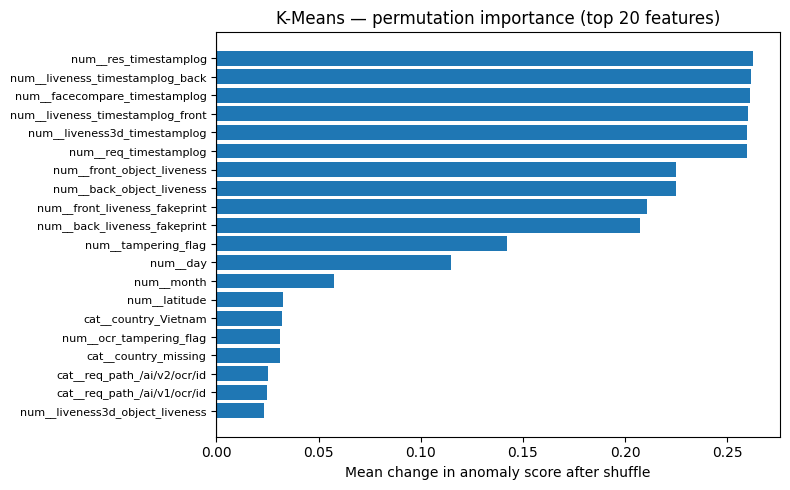

In [13]:
# --- 2. permutation importance ---
# shuffle each feature one at a time, measure mean change in anomaly score
import numpy as np

rng = np.random.default_rng(42)
base_score = train_dist.mean()

n_feat = X_train_model.shape[1]
deltas = np.zeros(n_feat)

for i in range(n_feat):
    X_perm = X_train_model.copy()
    rng.shuffle(X_perm[:, i])
    perm_dist = kmeans.transform(X_perm).min(axis=1)
    deltas[i] = perm_dist.mean() - base_score

# sort by absolute impact
order = np.argsort(np.abs(deltas))[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(order)), deltas[order])
ax.set_yticks(range(len(order)))
ax.set_yticklabels([feat_names[i] for i in order], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean change in anomaly score after shuffle")
ax.set_title("K-Means — permutation importance (top 20 features)")
plt.tight_layout()
plt.show()


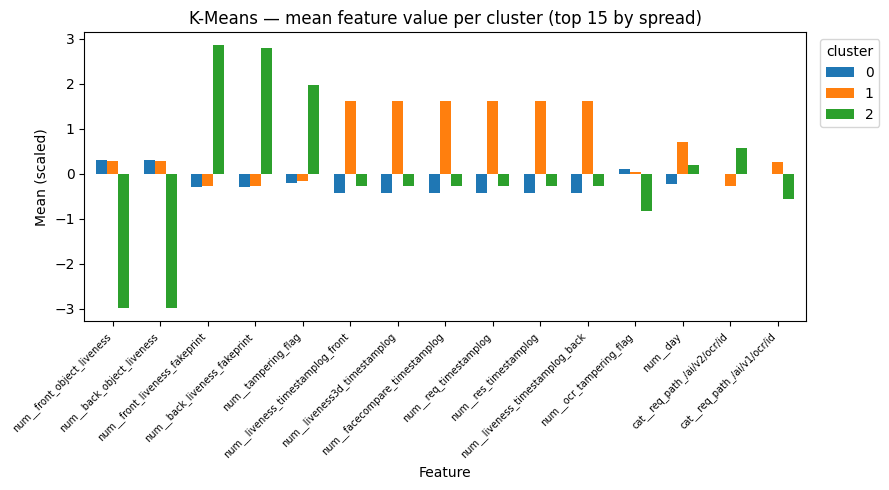

In [14]:
# --- 3. mean feature value per cluster ---
# which features have the largest spread across clusters?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_cl = pd.DataFrame(X_train_model, columns=feat_names)
df_cl["cluster"] = kmeans.labels_

cluster_means = df_cl.groupby("cluster").mean()

# pick top 15 features by variance of cluster means
spread = cluster_means.var(axis=0).sort_values(ascending=False).head(15)
top_features = spread.index.tolist()

fig, ax = plt.subplots(figsize=(9, 5))
cluster_means[top_features].T.plot(kind="bar", ax=ax, width=0.7)
ax.set_xlabel("Feature")
ax.set_ylabel("Mean (scaled)")
ax.set_title("K-Means — mean feature value per cluster (top 15 by spread)")
ax.legend(title="cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()
